In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from scipy import stats as st
from scipy.stats import describe

#### Importamos el dataset
---

In [55]:
import huggingface_hub

df = pd.read_csv("hf://datasets/swisscondor/football-transfers/transfers.csv")

In [56]:
df.head()

,Player,Position,Age,Market Value,Nationality,Left Club,Joined Club,Season,Transfer Fee
0,Neymar,Left Winger,25,€100.00m,Brazil,FC Barcelona,Paris Saint-Germain,17/18,€222.00m
1,Kylian Mbappé,Centre-Forward,19,€120.00m,France,AS Monaco,Paris Saint-Germain,18/19,€180.00m
2,Philippe Coutinho,Attacking Midfield,25,€90.00m,Brazil,Liverpool FC,FC Barcelona,17/18,€135.00m
3,Ousmane Dembélé,Right Winger,20,€33.00m,France,Borussia Dortmund,FC Barcelona,17/18,€135.00m
4,João Félix,Second Striker,19,€70.00m,Portugal,SL Benfica,Atlético de Madrid,19/20,€127.20m


#### Variables

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Player        250 non-null    str  
 1   Position      250 non-null    str  
 2   Age           250 non-null    int64
 3   Market Value  250 non-null    str  
 4   Nationality   250 non-null    str  
 5   Left Club     250 non-null    str  
 6   Joined Club   250 non-null    str  
 7   Season        250 non-null    str  
 8   Transfer Fee  250 non-null    str  
dtypes: int64(1), str(8)
memory usage: 17.7 KB


#### Duplicados

In [58]:
# Check for duplicate IDs
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\n Found {duplicate_ids} duplicates")
else:
    print("\nAll transfers are unique")


All transfers are unique


#### Nulos

In [59]:
# Normalize Transfer Fee data
df['Transfer Fee'] = (
    df['Transfer Fee']
    .str.replace(r'[€m]', '', regex=True) # Remove € and m
    .astype(float)                        # Convert to float
    * 1_000_000                           # Scale to millions
)

In [60]:
nul_transfers = df['Transfer Fee'][df['Transfer Fee'] == 0]
print(f"Found {len(nul_transfers)} nul transfers")

Found 0 nul transfers


#### Outliers

In [61]:
Q1 = df['Transfer Fee'].quantile(0.25)
Q2 = df['Transfer Fee'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q3 = df['Transfer Fee'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

Q1 (25%): 44525000.0
Q2 (Mediana, 50%): 52000000.0
Q3 (75%): 65225000.0


In [62]:
df['Transfer Fee']

0      222000000.0
1      180000000.0
2      135000000.0
3      135000000.0
4      127200000.0
          ...     
245     40000000.0
246     40000000.0
247     40000000.0
248     40000000.0
249     40000000.0
Name: Transfer Fee, Length: 250, dtype: float64

In [63]:
IQR = Q3 - Q1
print("Rango intercuartil (IQR):", IQR)

Rango intercuartil (IQR): 20700000.0


#### Boxplots Quartils

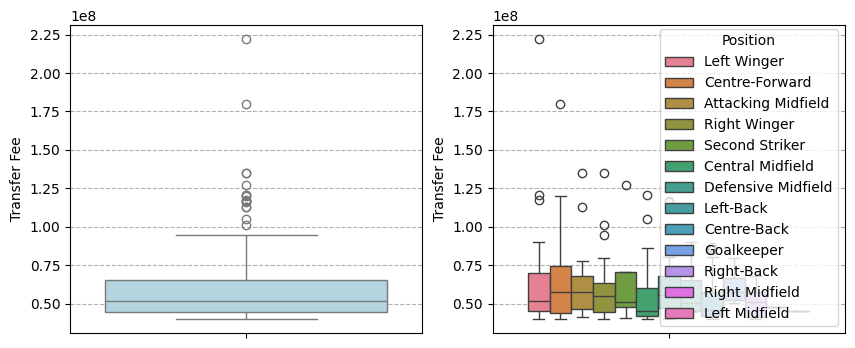

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='Transfer Fee', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='Transfer Fee', hue='Position', ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='Position', loc='lower right')


plt.show()

#### Skeweness y Curtosis

In [73]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var: {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std: {std:.2f}', fontsize=10, color='red')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [74]:
print(f"Asímetría de la variable masa_corporal: {df['Transfer Fee'].skew()}")
print(f"Curtosis de la variable masa_corporal: {df['Transfer Fee'].kurtosis()}")

Asímetría de la variable masa_corporal: 2.666870471035289
Curtosis de la variable masa_corporal: 10.956295729577901


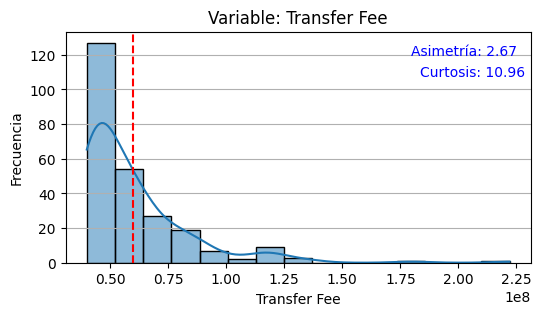

In [75]:
plot_histograma(df, 'Transfer Fee',mvd= False, snk=True)